This notebook contains all models built for this project


The following regression models will be built for this project:
- Linear Regression (Multiple, Lasso, Ridge, Elastic net)
- Regression Trees/ Random Forest Regression
- XGBoost Regression

In [367]:
# Import libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from statsmodels.api import OLS
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV
import seaborn as sns
from sklearn.metrics import PredictionErrorDisplay

In [368]:
# Read in the data
players = pd.read_csv(r'../Data/final_player_data.csv')

# Graphing potential predictors with the target

Before modeling, we need to analyze the relationships with the target and potential predictors. This will allow us to see if a linear regression model will be a fit.

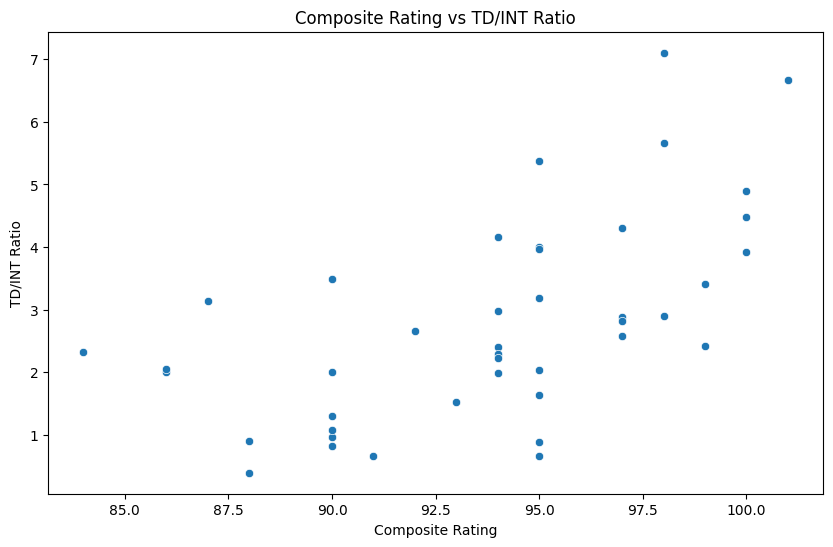

In [369]:
# Examine scout rating vs TD/int ratio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='composite_rating', y='TD/INT_Ratio_player_after_enrollment', data=players)
plt.title('Composite Rating vs TD/INT Ratio')
plt.xlabel('Composite Rating')
plt.ylabel('TD/INT Ratio')
plt.show()

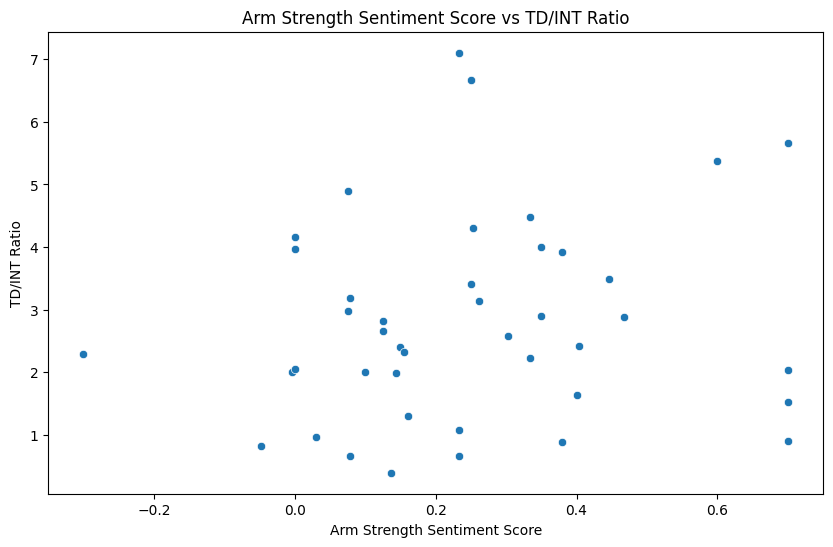

In [370]:
# Examine Arm_Strength_sentiment_score vs TD/int ratio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Arm_Strength_sentiment_score', y='TD/INT_Ratio_player_after_enrollment', data=players)
plt.title('Arm Strength Sentiment Score vs TD/INT Ratio')
plt.xlabel('Arm Strength Sentiment Score')
plt.ylabel('TD/INT Ratio')
plt.show()

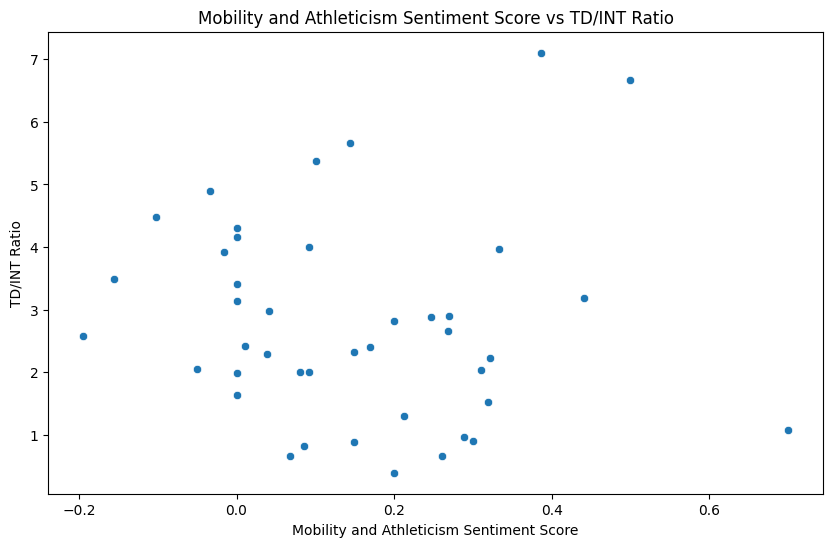

In [371]:
# Examine Mobility_and_Athleticism_sentiment_score vs TD/int ratio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Mobility_and_Athleticism_sentiment_score', y='TD/INT_Ratio_player_after_enrollment', data=players)
plt.title('Mobility and Athleticism Sentiment Score vs TD/INT Ratio')
plt.xlabel('Mobility and Athleticism Sentiment Score')
plt.ylabel('TD/INT Ratio')
plt.show()

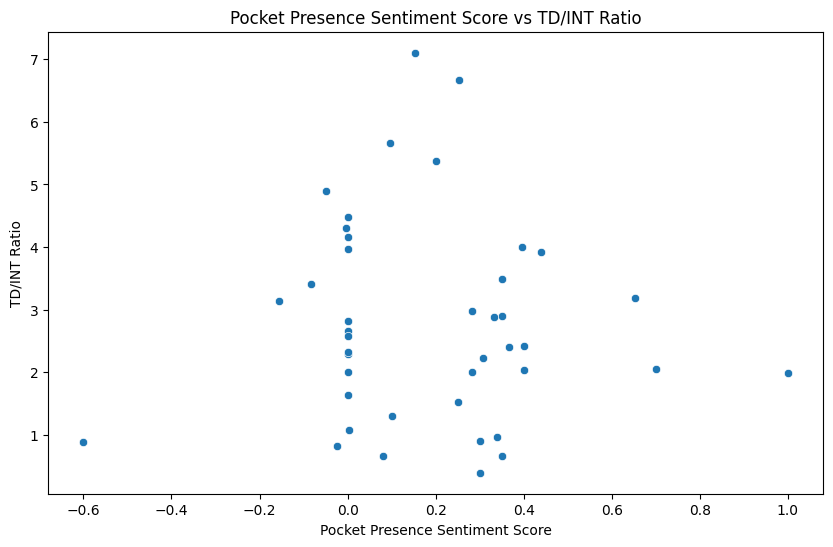

In [372]:
# Examine Pocket_Presence_sentiment_score vs TD/int ratio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Pocket_Presence_sentiment_score', y='TD/INT_Ratio_player_after_enrollment', data=players)
plt.title('Pocket Presence Sentiment Score vs TD/INT Ratio')
plt.xlabel('Pocket Presence Sentiment Score')
plt.ylabel('TD/INT Ratio')
plt.show()

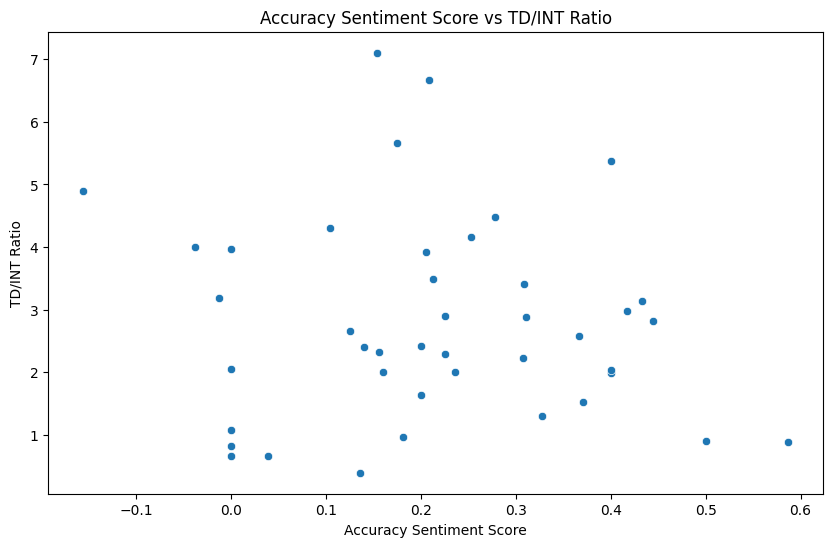

In [373]:
# Examine Accuracy_sentiment_score vs TD/int ratio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Accuracy_sentiment_score', y='TD/INT_Ratio_player_after_enrollment', data=players)
plt.title('Accuracy Sentiment Score vs TD/INT Ratio')
plt.xlabel('Accuracy Sentiment Score')
plt.ylabel('TD/INT Ratio')
plt.show()

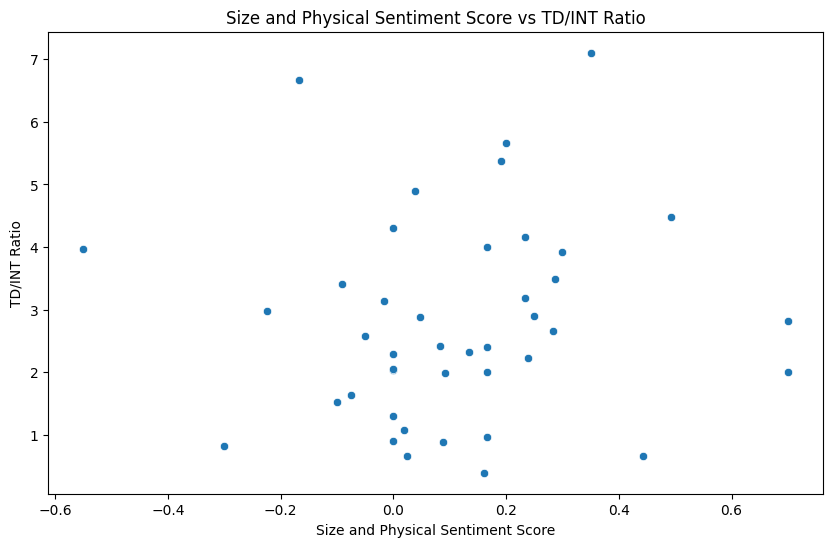

In [374]:
# Examine Size_and_Physical_sentiment_score vs TD/int ratio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Size_and_Physical_sentiment_score', y='TD/INT_Ratio_player_after_enrollment', data=players)
plt.title('Size and Physical Sentiment Score vs TD/INT Ratio')
plt.xlabel('Size and Physical Sentiment Score')
plt.ylabel('TD/INT Ratio')
plt.show()

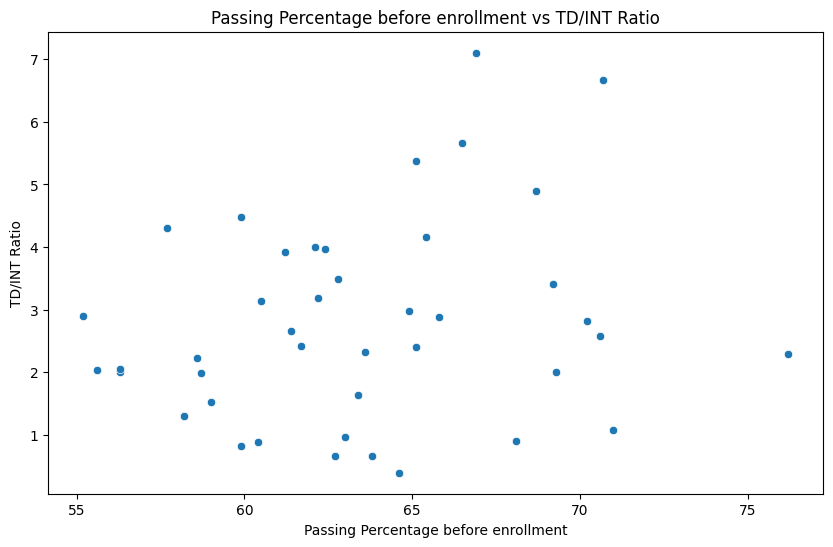

In [375]:
# Examine Passing percentage before enrollment vs TD/int ratio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='passing_pct_team_before_enrollment', y='TD/INT_Ratio_player_after_enrollment', data=players)
plt.title('Passing Percentage before enrollment vs TD/INT Ratio')
plt.xlabel('Passing Percentage before enrollment')
plt.ylabel('TD/INT Ratio')
plt.show()

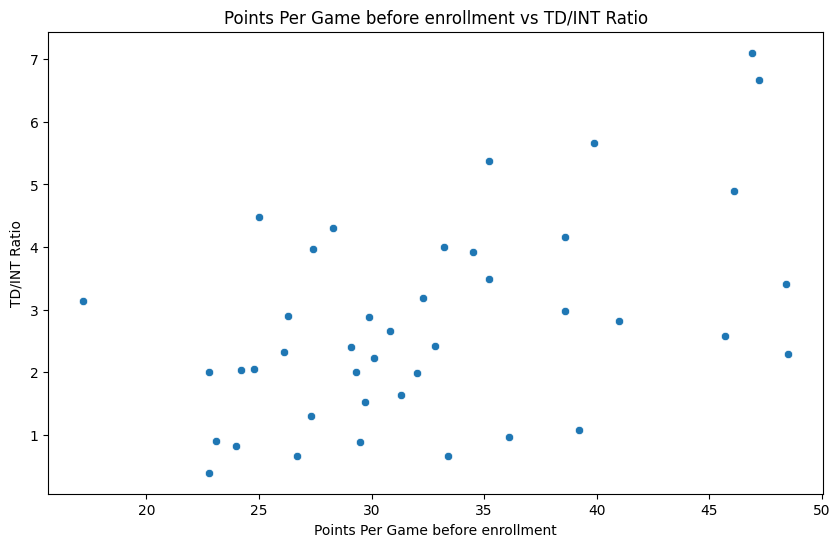

In [376]:
# Examine Points Per Game before enrollment vs TD/int ratio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='ppg_offense_team_before_enrollment', y='TD/INT_Ratio_player_after_enrollment', data=players)
plt.title('Points Per Game before enrollment vs TD/INT Ratio')
plt.xlabel('Points Per Game before enrollment')
plt.ylabel('TD/INT Ratio')
plt.show()

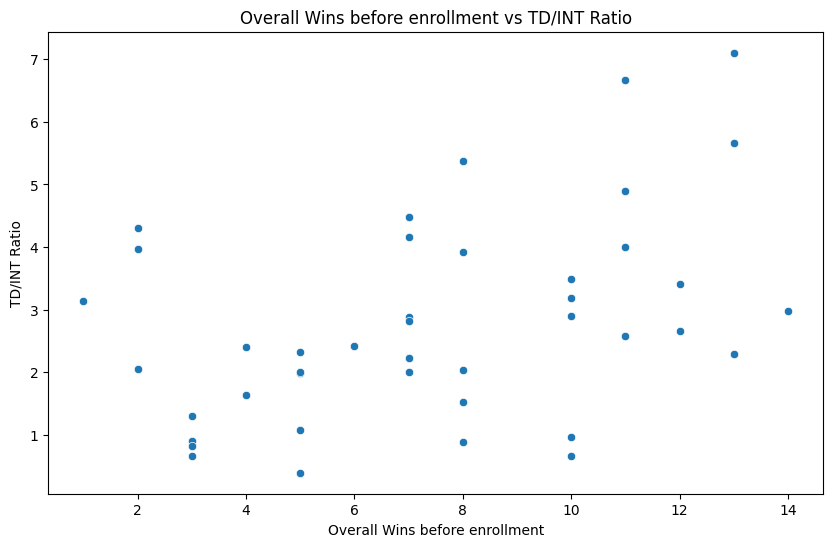

In [377]:
# Examine Overall Wins before enrollment vs TD/int ratio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='overall_wins_team_before_enrollment', y='TD/INT_Ratio_player_after_enrollment', data=players)
plt.title('Overall Wins before enrollment vs TD/INT Ratio')
plt.xlabel('Overall Wins before enrollment')
plt.ylabel('TD/INT Ratio')
plt.show()

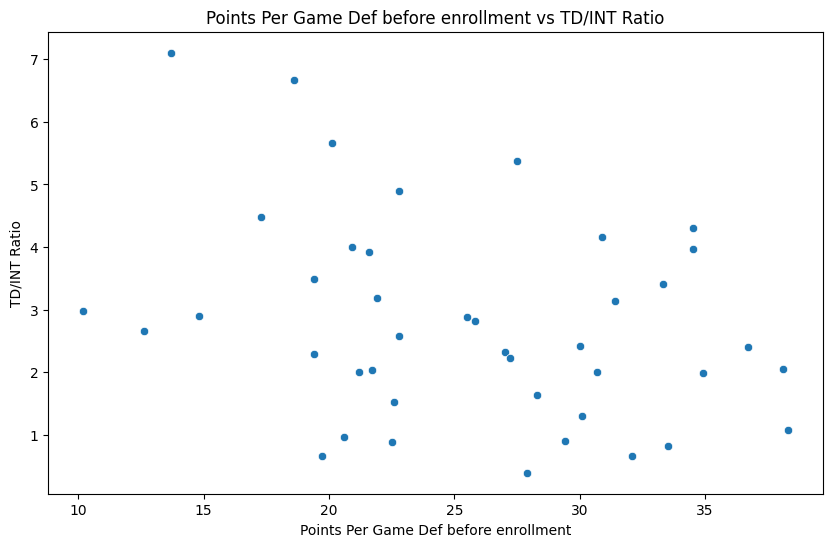

In [378]:
# Examine Points Per Game def before enrollment vs TD/int ratio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='ppg_defense_team_before_enrollment', y='TD/INT_Ratio_player_after_enrollment', data=players)
plt.title('Points Per Game Def before enrollment vs TD/INT Ratio')
plt.xlabel('Points Per Game Def before enrollment')
plt.ylabel('TD/INT Ratio')
plt.show()

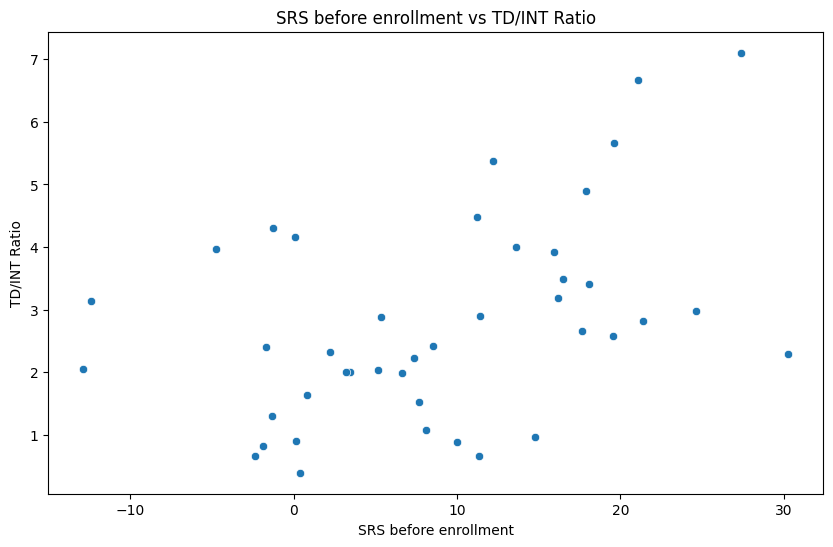

In [379]:
# Examine SRS before enrollment vs TD/int ratio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='srs_team_before_enrollment', y='TD/INT_Ratio_player_after_enrollment', data=players)
plt.title('SRS before enrollment vs TD/INT Ratio')
plt.xlabel('SRS before enrollment')
plt.ylabel('TD/INT Ratio')
plt.show()

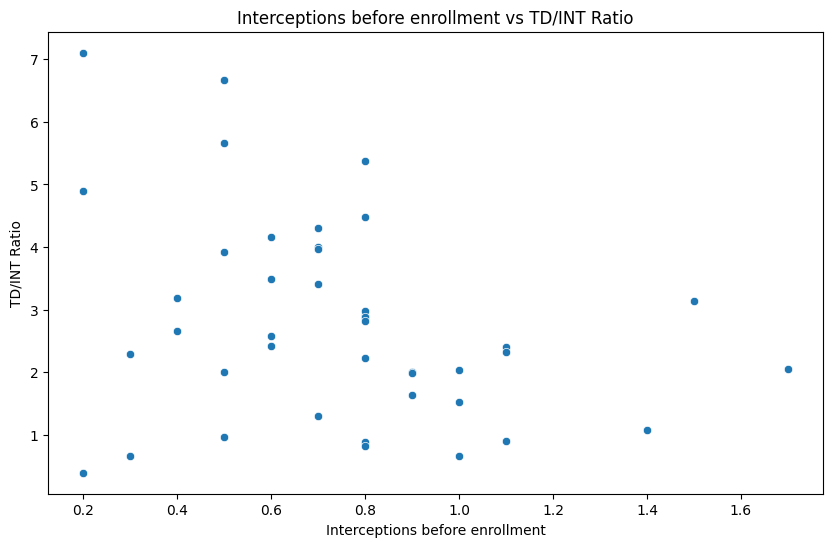

In [380]:
# Examine Interceptions before enrollment vs TD/int ratio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='interceptions_team_before_enrollment', y='TD/INT_Ratio_player_after_enrollment', data=players)
plt.title('Interceptions before enrollment vs TD/INT Ratio')
plt.xlabel('Interceptions before enrollment')
plt.ylabel('TD/INT Ratio')
plt.show()

The following look like they be important for linear regression modeling: 

- 'interceptions_team_before_enrollment'
- 'srs_team_before_enrollment'
- 'overall_wins_team_before_enrollment'
- 'ppg_offense_team_before_enrollment'
- 'composite_rating'

In [381]:
players.columns

Index(['player', 'url', 'recruiting_rank', 'height', 'weight',
       'composite_rating', 'high_school', 'city', 'state', 'draft_projection',
       'reminds_of', 'evaluated_date', 'analyst', 'athletic_background',
       'committed_school', 'numerical_rating', 'Is_FBS', 'Is_SEC',
       'Is_Big_Ten', 'Is_Big_XII', 'Is_ACC', 'pos_DUAL', 'pos_PRO', 'pos_QB',
       'star_2', 'star_3', 'star_4', 'star_5', 'Is_Top_Five_Ranked',
       'Is_From_East', 'Is_From_West', 'weight_to_height_ratio', 'bmi',
       'Accuracy_sentiment_score', 'Arm_Strength_sentiment_score',
       'Mobility_and_Athleticism_sentiment_score',
       'NFL_Draft_Projection_sentiment_score',
       'Pocket_Presence_sentiment_score', 'Size_and_Physical_sentiment_score',
       'games_played_player_after_enrollment',
       'completions_player_after_enrollment',
       'attempts_player_after_enrollment',
       'completion_pct_player_after_enrollment',
       'yards_player_after_enrollment', 'touchdowns_player_after_enrol

## Setting up for modeling:

Target: 'TD/INT_Ratio_player_after_enrollment'

_Predictors_ - Certain predictors such as player stats cannot be used as there would be data leakage and other variables have missingness or may not be useful for modeling purposes. From this, here is the list of predictors that will be used in modeling:

['recruiting_rank',
 'height',
 'weight',
 'composite_rating',
 'Is_FBS',
 'Is_SEC',
 'Is_Big_Ten',
 'Is_Big_XII',
 'Is_ACC',
 'pos_DUAL',
 'pos_PRO',
 'pos_QB',
 'star_2',
 'star_3',
 'star_4',
 'star_5',
 'Is_Top_Five_Ranked',
 'Is_From_East',
 'Is_From_West',
 'weight_to_height_ratio',
 'bmi',
 'Accuracy_sentiment_score',
 'Arm_Strength_sentiment_score',
 'Mobility_and_Athleticism_sentiment_score',
 'NFL_Draft_Projection_sentiment_score',
 'Pocket_Presence_sentiment_score',
 'Size_and_Physical_sentiment_score',
 'games_played_team_before_enrollment',
       'ppg_team_before_enrollment',
       'passing_completions_team_before_enrollment',
       'passing_attempts_team_before_enrollment',
       'passing_pct_team_before_enrollment',
       'passing_yards_team_before_enrollment',
       'passing_touchdowns_team_before_enrollment',
       'rushing_attempts_team_before_enrollment',
       'rushing_yards_team_before_enrollment',
       'rushing_average_team_before_enrollment',
       'rushing_touchdowns_team_before_enrollment',
       'offensive_plays_team_before_enrollment',
       'offensive_yards_team_before_enrollment',
       'offensive_average_team_before_enrollment',
       'first_down_passes_team_before_enrollment',
       'first_down_rushes_team_before_enrollment',
       'first_down_penalties_team_before_enrollment',
       'first_downs_team_before_enrollment',
       'penalty_counts_team_before_enrollment',
       'penalty_yards_team_before_enrollment',
       'fumbles_team_before_enrollment',
       'interceptions_team_before_enrollment',
       'total_turnovers_team_before_enrollment',
       'overall_wins_team_before_enrollment',
       'overall_losses_team_before_enrollment',
       'overall_win_pct_team_before_enrollment',
       'conference_wins_team_before_enrollment',
       'conference_losses_team_before_enrollment',
       'conference_win_pct_team_before_enrollment',
       'ppg_offense_team_before_enrollment',
       'ppg_defense_team_before_enrollment', 
       'srs_team_before_enrollment',
       'sos_team_before_enrollment',
       'final_ranking_team_AP_top_10_before_enrollment',
       'highest_ranking_team_AP_top_10_before_enrollment']

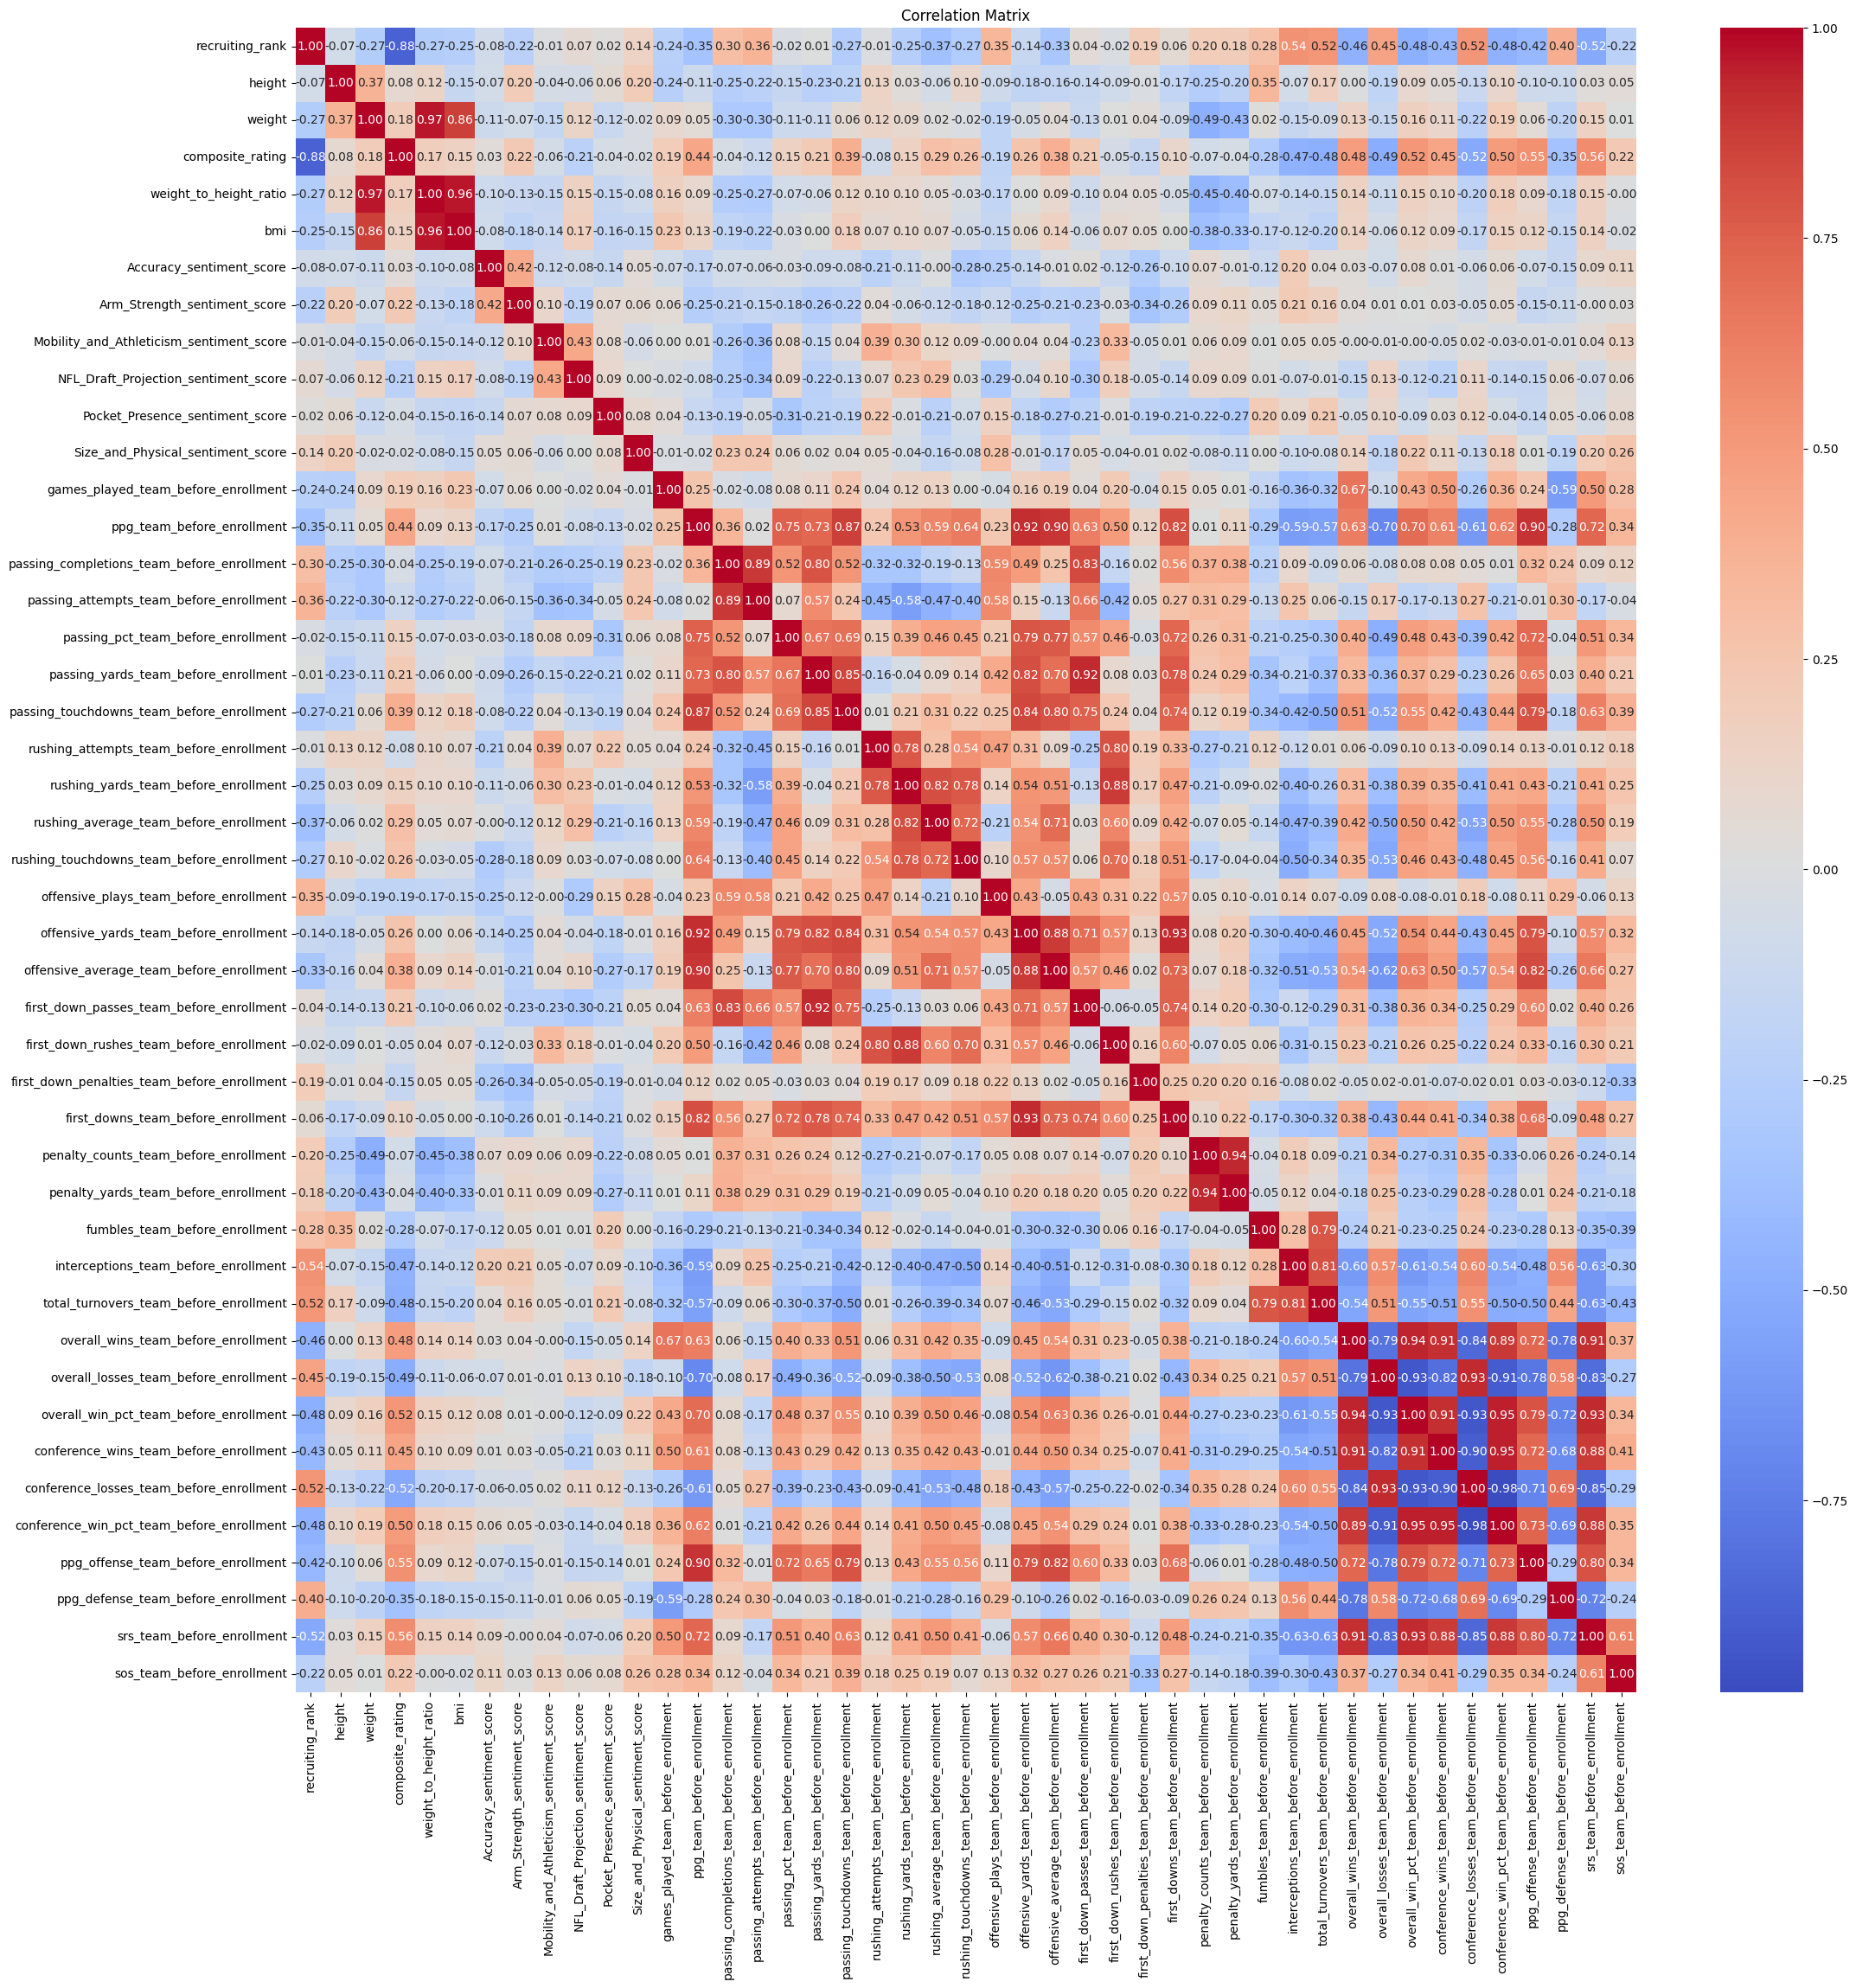

In [382]:
# Examine the correlation between the features and the target variable (boolean features excluded)
correlation_matrix = players[['recruiting_rank',
 'height',
 'weight',
 'composite_rating',
 'weight_to_height_ratio',
 'bmi',
 'Accuracy_sentiment_score',
 'Arm_Strength_sentiment_score',
 'Mobility_and_Athleticism_sentiment_score',
 'NFL_Draft_Projection_sentiment_score',
 'Pocket_Presence_sentiment_score',
 'Size_and_Physical_sentiment_score',
 'games_played_team_before_enrollment',
       'ppg_team_before_enrollment',
       'passing_completions_team_before_enrollment',
       'passing_attempts_team_before_enrollment',
       'passing_pct_team_before_enrollment',
       'passing_yards_team_before_enrollment',
       'passing_touchdowns_team_before_enrollment',
       'rushing_attempts_team_before_enrollment',
       'rushing_yards_team_before_enrollment',
       'rushing_average_team_before_enrollment',
       'rushing_touchdowns_team_before_enrollment',
       'offensive_plays_team_before_enrollment',
       'offensive_yards_team_before_enrollment',
       'offensive_average_team_before_enrollment',
       'first_down_passes_team_before_enrollment',
       'first_down_rushes_team_before_enrollment',
       'first_down_penalties_team_before_enrollment',
       'first_downs_team_before_enrollment',
       'penalty_counts_team_before_enrollment',
       'penalty_yards_team_before_enrollment',
       'fumbles_team_before_enrollment',
       'interceptions_team_before_enrollment',
       'total_turnovers_team_before_enrollment',
       'overall_wins_team_before_enrollment',
       'overall_losses_team_before_enrollment',
       'overall_win_pct_team_before_enrollment',
       'conference_wins_team_before_enrollment',
       'conference_losses_team_before_enrollment',
       'conference_win_pct_team_before_enrollment',
       'ppg_offense_team_before_enrollment',
       'ppg_defense_team_before_enrollment', 
       'srs_team_before_enrollment',
       'sos_team_before_enrollment']].corr()

# Display the correlation matrix
plt.figure(figsize=(25, 25))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

Note: Lots of concerning correlations here. Let's record high correlations (>= 0.8 or <= -0.8) and remove certain predictors accordingly. 

In [383]:
# locate variables with high correlation to each other
correlation_matrix > 0.8

,recruiting_rank,height,weight,composite_rating,weight_to_height_ratio,bmi,Accuracy_sentiment_score,Arm_Strength_sentiment_score,Mobility_and_Athleticism_sentiment_score,NFL_Draft_Projection_sentiment_score,...,overall_wins_team_before_enrollment,overall_losses_team_before_enrollment,overall_win_pct_team_before_enrollment,conference_wins_team_before_enrollment,conference_losses_team_before_enrollment,conference_win_pct_team_before_enrollment,ppg_offense_team_before_enrollment,ppg_defense_team_before_enrollment,srs_team_before_enrollment,sos_team_before_enrollment
recruiting_rank,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
height,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
weight,False,False,True,False,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
composite_rating,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
weight_to_height_ratio,False,False,True,False,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
bmi,False,False,True,False,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Accuracy_sentiment_score,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Arm_Strength_sentiment_score,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
Mobility_and_Athleticism_sentiment_score,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
NFL_Draft_Projection_sentiment_score,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [384]:
correlation_matrix[correlation_matrix.abs() > 0.8]

,recruiting_rank,height,weight,composite_rating,weight_to_height_ratio,bmi,Accuracy_sentiment_score,Arm_Strength_sentiment_score,Mobility_and_Athleticism_sentiment_score,NFL_Draft_Projection_sentiment_score,...,overall_wins_team_before_enrollment,overall_losses_team_before_enrollment,overall_win_pct_team_before_enrollment,conference_wins_team_before_enrollment,conference_losses_team_before_enrollment,conference_win_pct_team_before_enrollment,ppg_offense_team_before_enrollment,ppg_defense_team_before_enrollment,srs_team_before_enrollment,sos_team_before_enrollment
recruiting_rank,1.000000,NaN,NaN,-0.881276,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,NaN,NaN,1.000000,NaN,0.967174,0.861458,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
composite_rating,-0.881276,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight_to_height_ratio,NaN,NaN,0.967174,NaN,1.000000,0.962209,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,NaN,NaN,0.861458,NaN,0.962209,1.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Accuracy_sentiment_score,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Arm_Strength_sentiment_score,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mobility_and_Athleticism_sentiment_score,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NFL_Draft_Projection_sentiment_score,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [385]:
def find_high_correlations(df, threshold=0.8):
    corr = df.corr()
    
    # Get upper triangle only (avoid duplicates + self-correlations)
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    
    # Stack, drop NaNs, filter by threshold
    high_corr = (
        upper.stack()
             .reset_index()
             .rename(columns={"level_0": "var1", "level_1": "var2", 0: "correlation"})
    )
    high_corr = high_corr[high_corr["correlation"].abs() >= threshold]
    high_corr = high_corr.sort_values("correlation", ascending=False)
    
    return high_corr

In [386]:
find_high_correlations(correlation_matrix, threshold=0.8)

,var1,var2,correlation
1705,overall_win_pct_team_before_enrollment,conference_win_pct_team_before_enrollment,0.995547
1750,conference_wins_team_before_enrollment,conference_win_pct_team_before_enrollment,0.993698
1703,overall_win_pct_team_before_enrollment,conference_wins_team_before_enrollment,0.992641
1613,overall_wins_team_before_enrollment,conference_wins_team_before_enrollment,0.992244
1708,overall_win_pct_team_before_enrollment,srs_team_before_enrollment,0.992221
...,...,...,...
1749,conference_wins_team_before_enrollment,conference_losses_team_before_enrollment,-0.984670
1660,overall_losses_team_before_enrollment,conference_win_pct_team_before_enrollment,-0.988014
1657,overall_losses_team_before_enrollment,overall_win_pct_team_before_enrollment,-0.991063
1704,overall_win_pct_team_before_enrollment,conference_losses_team_before_enrollment,-0.992431


Examples of very high correlated variables:

- conference_win_pct_team_before_enrollment
- conference_wins_team_before_enrollment
- conference_losses_team_before_enrollment
- overall_win_pct_team_before_enrollment
- ppg_team_before_enrollment
- first_down_passes_team_before_enrollment

These examples are expected as they affect one another. Being cautious of this, let's move forward with multiple linear regression. 


Before going any further, we need to take out 1 variable from each dummy variable group. Let's remove the following:

- 'star_2'
- 'Is_From_West'
- 'pos_QB'
- 'Is_ACC'

---
# Multiple Linear Regression

---

Going forward, each section will be the compilation of several models with differing predictor sets and experiments to find the best model.

## **Model 1:**

In [387]:
# Create the predictor variables and the target variable
X = players[['height', 'weight',
       'composite_rating', 'Is_FBS', 'Is_SEC',
       'Is_Big_Ten', 'Is_Big_XII', 'pos_DUAL', 'pos_PRO',
       'star_3', 'star_4', 'star_5', 'Is_Top_Five_Ranked',
       'Is_From_East',  'Accuracy_sentiment_score', 'Arm_Strength_sentiment_score',
       'Mobility_and_Athleticism_sentiment_score',
       'Pocket_Presence_sentiment_score', 'Size_and_Physical_sentiment_score', 'passing_pct_team_before_enrollment',
       'passing_yards_team_before_enrollment',
       'passing_touchdowns_team_before_enrollment', 'rushing_average_team_before_enrollment',
       'rushing_touchdowns_team_before_enrollment', 'offensive_yards_team_before_enrollment', 'penalty_counts_team_before_enrollment', 'fumbles_team_before_enrollment',
       'interceptions_team_before_enrollment', 'overall_wins_team_before_enrollment',
       'overall_losses_team_before_enrollment', 'ppg_offense_team_before_enrollment',
       'ppg_defense_team_before_enrollment', 'srs_team_before_enrollment',  'final_ranking_team_AP_top_10_before_enrollment',
       'highest_ranking_team_AP_top_10_before_enrollment']]

y = players['TD/INT_Ratio_player_after_enrollment']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create scaler object to scale the features
scaler = StandardScaler()

# Scale the features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [388]:
# Create linear regression model
model_1 = sm.OLS(y_train, X_train_scaled).fit()

# Print the model summary
print(model_1.summary())

                                          OLS Regression Results                                         
Dep. Variable:     TD/INT_Ratio_player_after_enrollment   R-squared (uncentered):                   0.239
Model:                                              OLS   Adj. R-squared (uncentered):            -24.126
Method:                                   Least Squares   F-statistic:                           0.009793
Date:                                  Fri, 05 Jun 2026   Prob (F-statistic):                        1.00
Time:                                          12:21:17   Log-Likelihood:                         -83.199
No. Observations:                                    33   AIC:                                      230.4
Df Residuals:                                         1   BIC:                                      278.3
Df Model:                                            32                                                  
Covariance Type:                              

Very poor results; let's get the predictions and examine the MSE and RMSE.

In [389]:
# Predict on the test set
y_hat = model_1.predict(X_test_scaled)

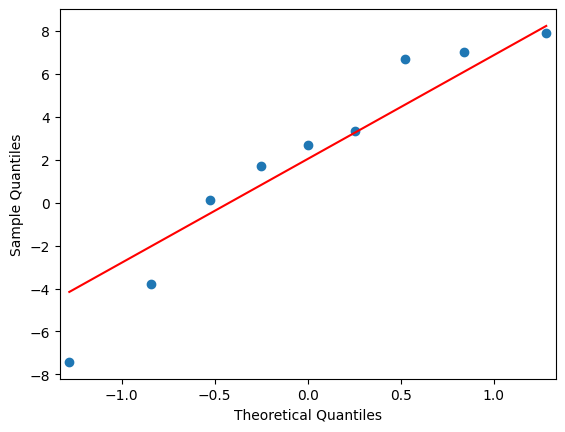

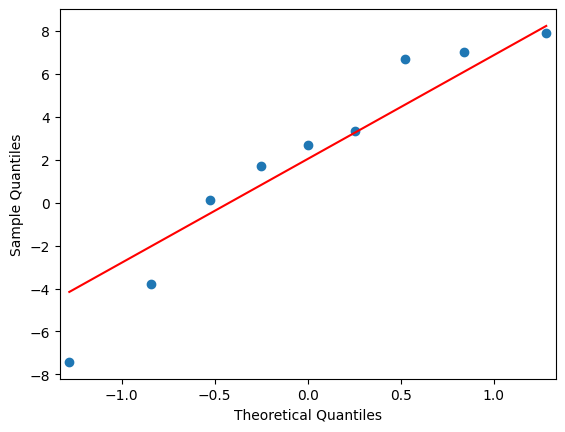

In [390]:
# Look at qq plot
sm.qqplot(y_test - y_hat, line='s')

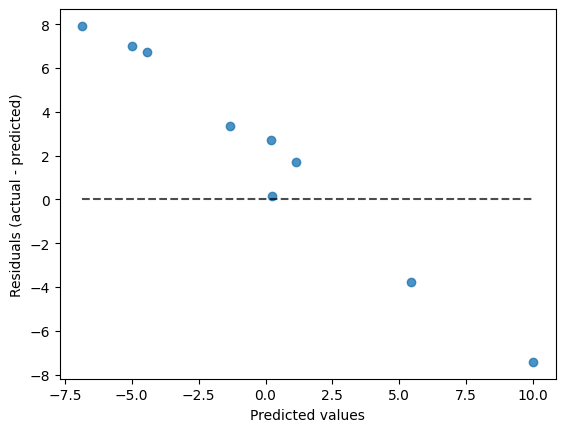

In [391]:
display = PredictionErrorDisplay(y_true = y_test, y_pred = y_hat)
display.plot()
plt.show()

In [392]:
# Get the Mean Squared Error
mse = mean_squared_error(y_test, y_hat)

# Get the Root Mean Squared Error
rmse = np.sqrt(mse)

# Print the results
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')

Mean Squared Error: 27.55756833681913
Root Mean Squared Error: 5.2495302967807635


Very bad model; high rmse and mse, negative R^2 adj, negative pattern present in the prediction error plot. The only positive is the normal pattern in the qqplot, meeting the normality assumption.


This means there are a lot of noisy and unimportant features in the model. Let's examine which features to take out of the model.

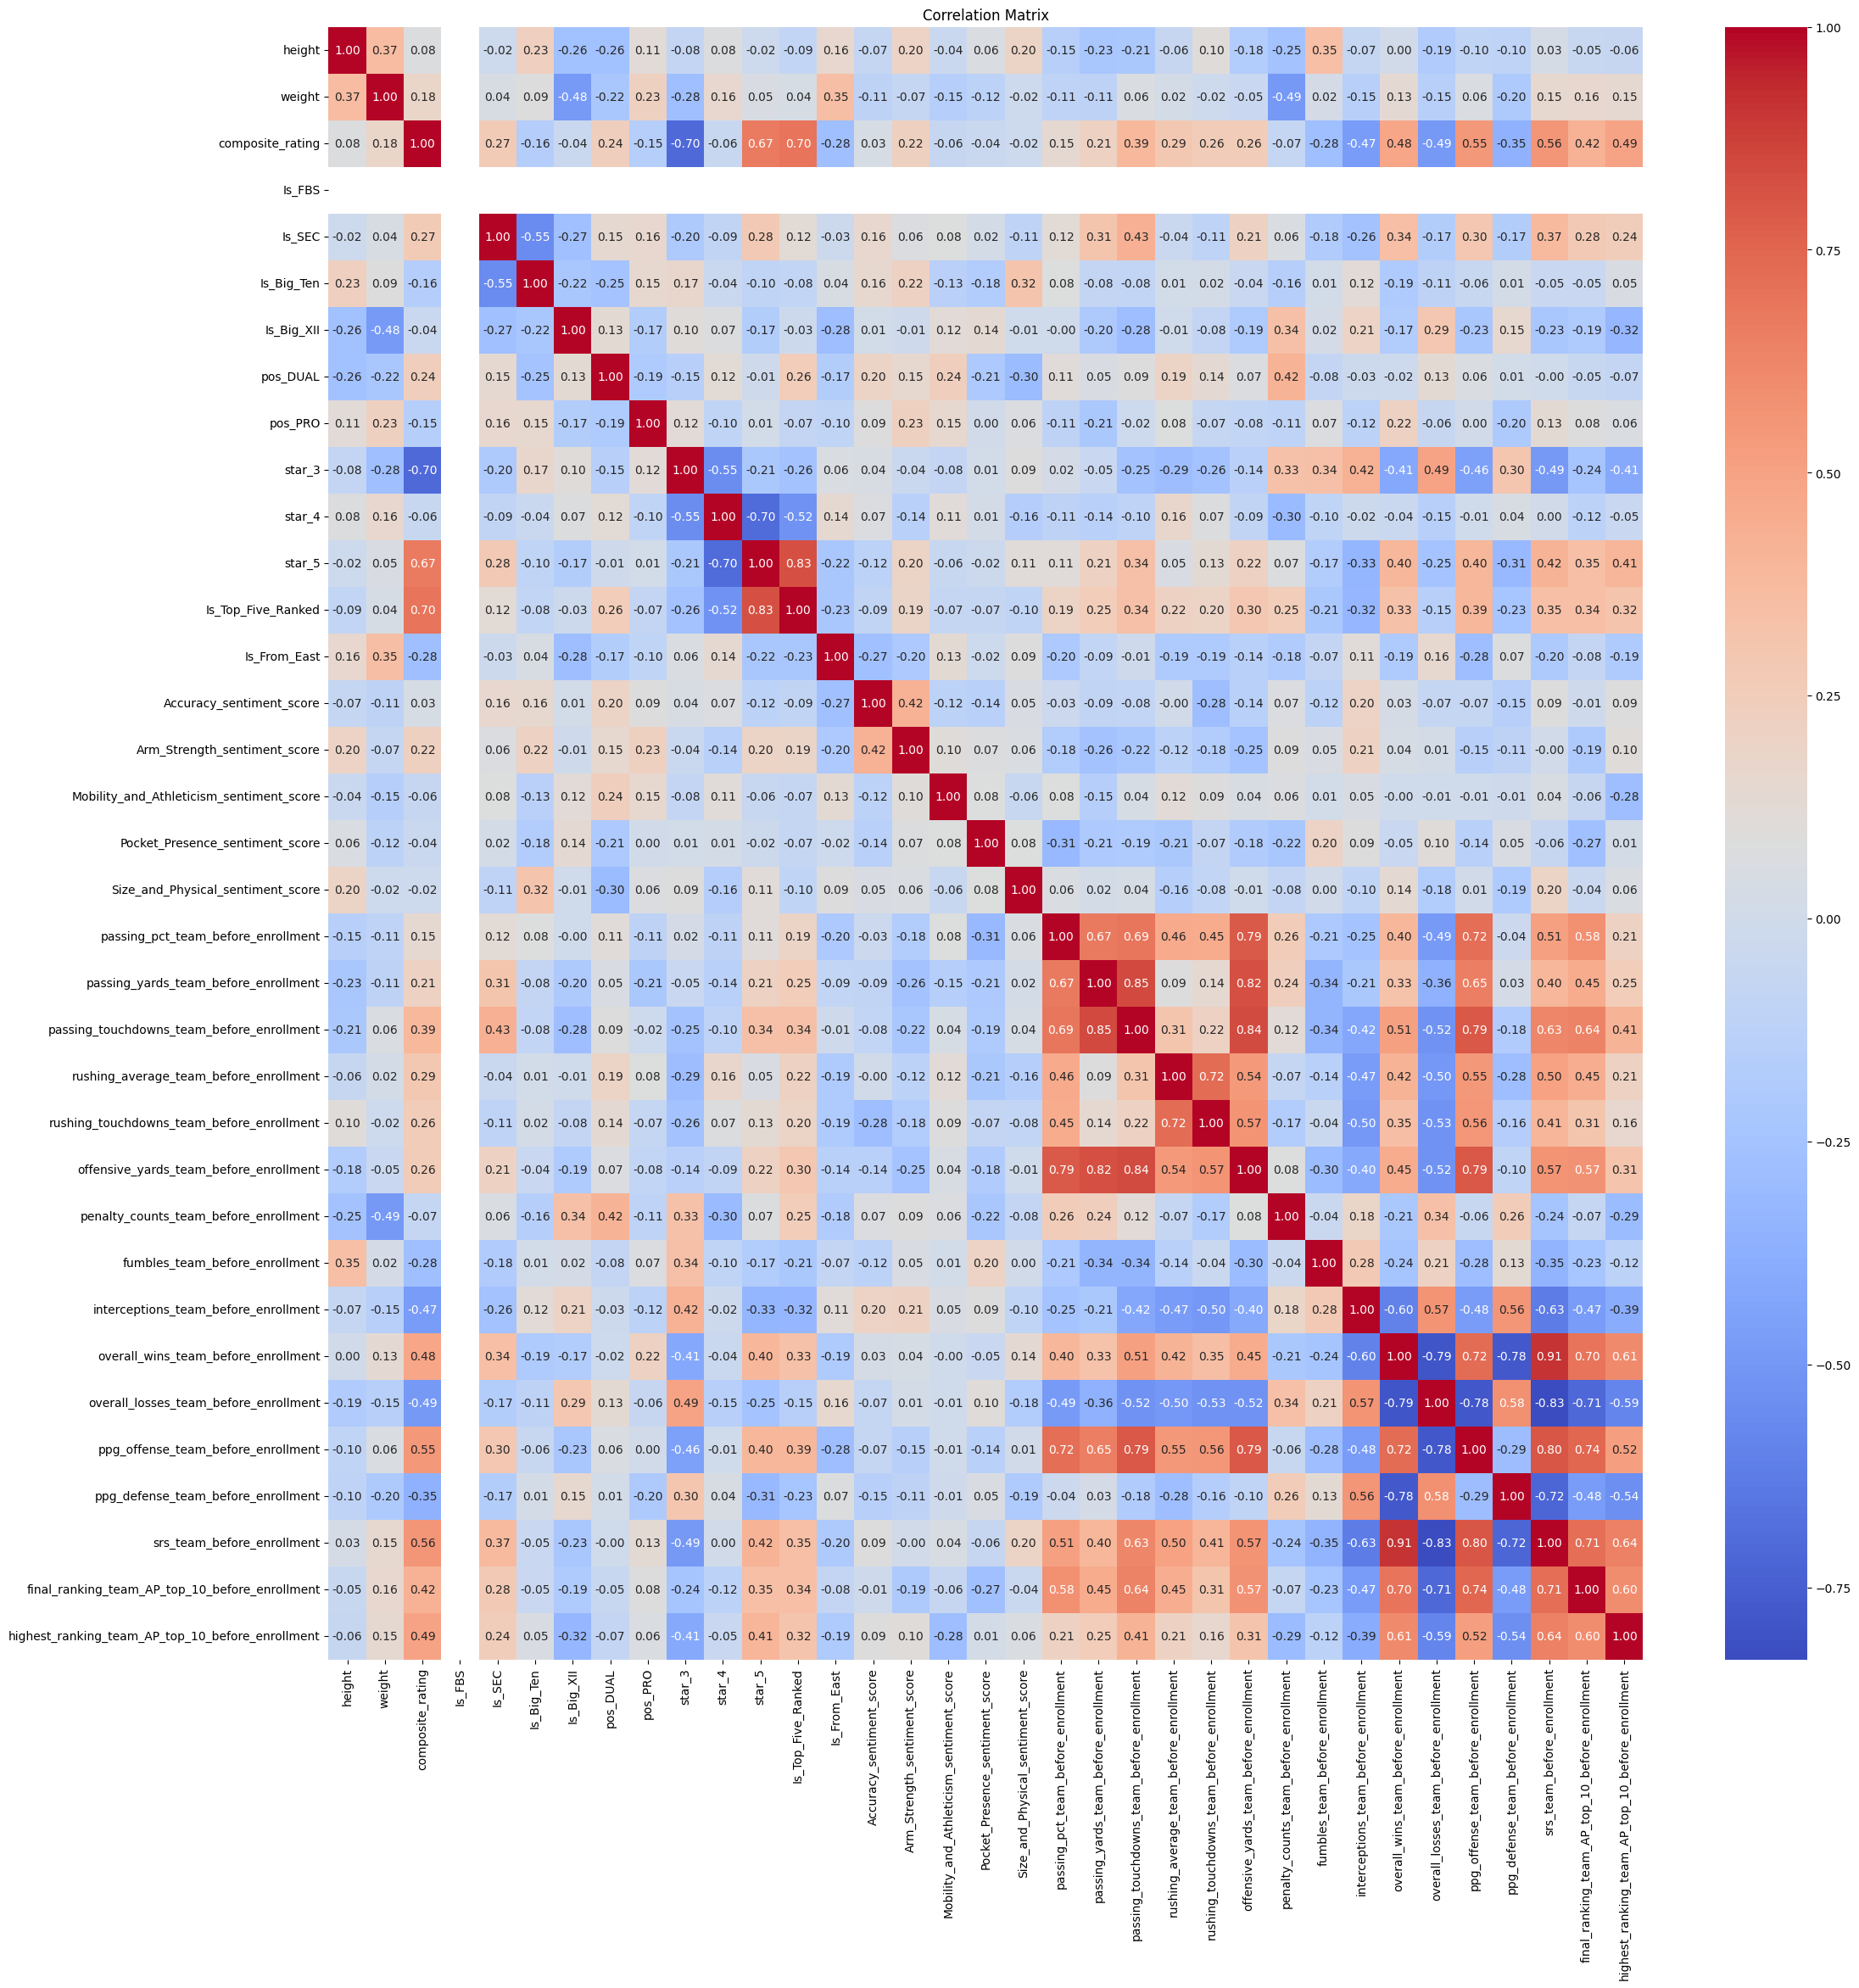

In [393]:
# Examine the correlation between the features
correlation_matrix = X.corr()
# Display the correlation matrix
plt.figure(figsize=(25, 25))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [394]:
X.columns

Index(['height', 'weight', 'composite_rating', 'Is_FBS', 'Is_SEC',
       'Is_Big_Ten', 'Is_Big_XII', 'pos_DUAL', 'pos_PRO', 'star_3', 'star_4',
       'star_5', 'Is_Top_Five_Ranked', 'Is_From_East',
       'Accuracy_sentiment_score', 'Arm_Strength_sentiment_score',
       'Mobility_and_Athleticism_sentiment_score',
       'Pocket_Presence_sentiment_score', 'Size_and_Physical_sentiment_score',
       'passing_pct_team_before_enrollment',
       'passing_yards_team_before_enrollment',
       'passing_touchdowns_team_before_enrollment',
       'rushing_average_team_before_enrollment',
       'rushing_touchdowns_team_before_enrollment',
       'offensive_yards_team_before_enrollment',
       'penalty_counts_team_before_enrollment',
       'fumbles_team_before_enrollment',
       'interceptions_team_before_enrollment',
       'overall_wins_team_before_enrollment',
       'overall_losses_team_before_enrollment',
       'ppg_offense_team_before_enrollment',
       'ppg_defense_team_before_en

For the next model let's remove:

- All Star ranking boolean variables ('star_3', 'star_4', 'star_5')
- 'passing_yards_team_before_enrollment'
- 'passing_pct_team_before_enrollment'
- 'offensive_yards_team_before_enrollment'
- 'srs_team_before_enrollment'
- 'ppg_offense_team_before_enrollment'

In [395]:
X = X.drop(columns=['star_3', 'star_4', 'star_5',
                     'passing_yards_team_before_enrollment','passing_pct_team_before_enrollment',
                     'offensive_yards_team_before_enrollment', 'srs_team_before_enrollment', 'ppg_offense_team_before_enrollment'])

## **Model 2:**

In [396]:
# With the reduced set of features, split the data into training and testing sets again
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale the features again
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create linear regression model
model_2 = sm.OLS(y_train, X_train_scaled).fit()

# Get the summary of the model
print(model_2.summary())

                                          OLS Regression Results                                         
Dep. Variable:     TD/INT_Ratio_player_after_enrollment   R-squared (uncentered):                   0.202
Model:                                              OLS   Adj. R-squared (uncentered):             -2.761
Method:                                   Least Squares   F-statistic:                            0.06821
Date:                                  Fri, 05 Jun 2026   Prob (F-statistic):                        1.00
Time:                                          12:21:20   Log-Likelihood:                         -83.971
No. Observations:                                    33   AIC:                                      219.9
Df Residuals:                                         7   BIC:                                      258.9
Df Model:                                            26                                                  
Covariance Type:                              

In [397]:
# Predict on the test set
y_hat = model_2.predict(X_test_scaled)

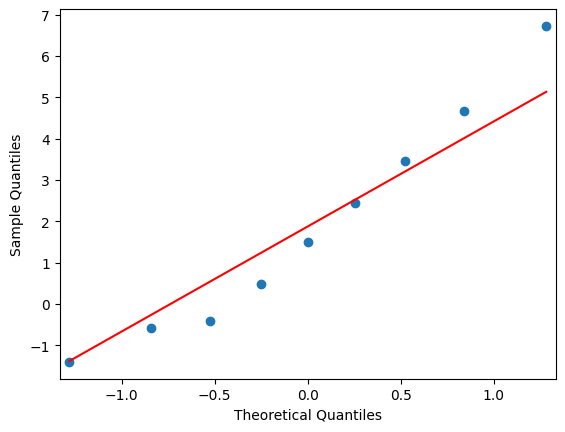

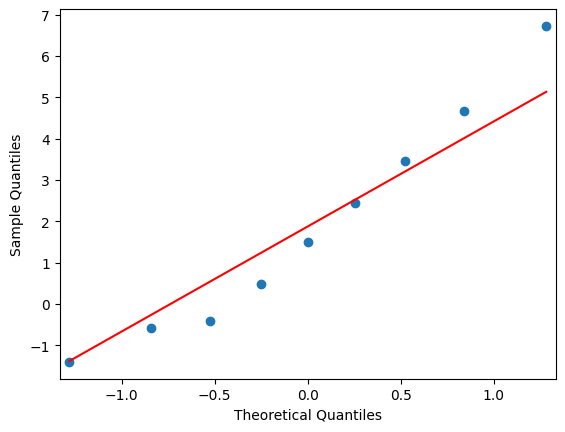

In [398]:
# Look at qq plot
sm.qqplot(y_test - y_hat, line='s')

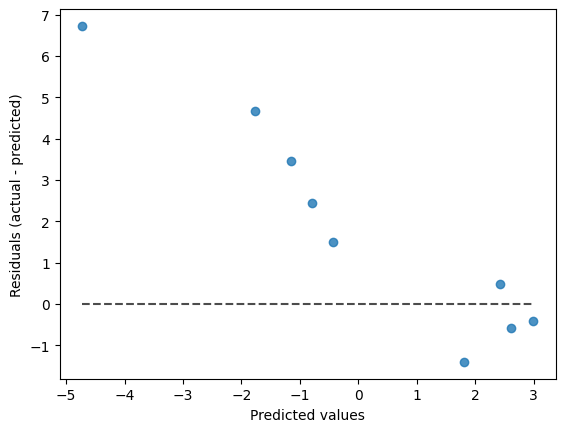

In [399]:
display = PredictionErrorDisplay(y_true = y_test, y_pred = y_hat)
display.plot()
plt.show()

In [400]:
# Get the Mean Squared Error
mse = mean_squared_error(y_test, y_hat)

# Get the Root Mean Squared Error
rmse = np.sqrt(mse)

# Print the results
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')

Mean Squared Error: 9.97876673258794
Root Mean Squared Error: 3.1589186017667408


The results are quite a bit better but still suffer from the same issues. Let's examine the VIF.

In [401]:
# Examine the VIF values for the features
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

                                             feature          VIF
0                                             height     2.542899
1                                             weight     2.989698
2                                   composite_rating     8.664027
3                                             Is_FBS  9842.670560
4                                             Is_SEC     4.219412
5                                         Is_Big_Ten     5.850464
6                                         Is_Big_XII     2.842150
7                                           pos_DUAL     2.665815
8                                            pos_PRO     2.475558
9                                 Is_Top_Five_Ranked     5.533583
10                                      Is_From_East     2.219485
11                          Accuracy_sentiment_score     2.852771
12                      Arm_Strength_sentiment_score     2.936324
13          Mobility_and_Athleticism_sentiment_score     2.082605
14        

For model 3 let's remove: 

- 'overall_losses_team_before_enrollment'
- 'Is_ACC'
- 'Is_SEC'
- 'Is_Big_Ten'
- 'Is_Big_XII'

In [402]:
# Remove features with high VIF values
X = X.drop(columns=['overall_losses_team_before_enrollment', 'Is_SEC', 'Is_Big_Ten', 'Is_Big_XII'])

## **Model 3:**

In [403]:
# With the reduced set of features, split the data into training and testing sets again
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale the features again
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create linear regression model
model_3 = sm.OLS(y_train, X_train_scaled).fit()

# Get the summary of the model
print(model_3.summary())

                                          OLS Regression Results                                         
Dep. Variable:     TD/INT_Ratio_player_after_enrollment   R-squared (uncentered):                   0.181
Model:                                              OLS   Adj. R-squared (uncentered):             -1.456
Method:                                   Least Squares   F-statistic:                             0.1107
Date:                                  Fri, 05 Jun 2026   Prob (F-statistic):                        1.00
Time:                                          12:21:21   Log-Likelihood:                         -84.398
No. Observations:                                    33   AIC:                                      212.8
Df Residuals:                                        11   BIC:                                      245.7
Df Model:                                            22                                                  
Covariance Type:                              

## **Model 4**

We will take out more features that are less significant next.

In [405]:
# Drop highly correlated features
X = X.drop(columns=['Accuracy_sentiment_score', 'composite_rating', 'Is_Top_Five_Ranked', 'Is_From_East', 'height', 'weight', 'Is_FBS', 'pos_DUAL', 'pos_PRO', 'Is_From_East', 'Mobility_and_Athleticism_sentiment_score', 'rushing_touchdowns_team_before_enrollment',
       'penalty_counts_team_before_enrollment','fumbles_team_before_enrollment', 'Pocket_Presence_sentiment_score',
       'Size_and_Physical_sentiment_score','highest_ranking_team_AP_top_10_before_enrollment', 'final_ranking_team_AP_top_10_before_enrollment', 'rushing_average_team_before_enrollment','interceptions_team_before_enrollment',
       'overall_wins_team_before_enrollment', 'ppg_defense_team_before_enrollment'])

In [406]:
# With the reduced set of features, split the data into training and testing sets again
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale the features again
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create linear regression model
model_4 = sm.OLS(y_train, X_train_scaled).fit()

# Get the summary of the model
print(model_4.summary())

                                          OLS Regression Results                                         
Dep. Variable:     TD/INT_Ratio_player_after_enrollment   R-squared (uncentered):                   0.128
Model:                                              OLS   Adj. R-squared (uncentered):              0.072
Method:                                   Least Squares   F-statistic:                              2.272
Date:                                  Fri, 05 Jun 2026   Prob (F-statistic):                       0.120
Time:                                          12:21:21   Log-Likelihood:                         -85.440
No. Observations:                                    33   AIC:                                      174.9
Df Residuals:                                        31   BIC:                                      177.9
Df Model:                                             2                                                  
Covariance Type:                              

Interesting. After taking out certain predictors and analyzing results several times, only 1 feature has turned out to be statisitically distinguishable from 0. That variable being the teams passing tds before the player got there. Perhaps switching certain variables and putting in some more offensive related predictors may be in order.

## **Model 6:**

In [408]:
players.columns

Index(['player', 'url', 'recruiting_rank', 'height', 'weight',
       'composite_rating', 'high_school', 'city', 'state', 'draft_projection',
       'reminds_of', 'evaluated_date', 'analyst', 'athletic_background',
       'committed_school', 'numerical_rating', 'Is_FBS', 'Is_SEC',
       'Is_Big_Ten', 'Is_Big_XII', 'Is_ACC', 'pos_DUAL', 'pos_PRO', 'pos_QB',
       'star_2', 'star_3', 'star_4', 'star_5', 'Is_Top_Five_Ranked',
       'Is_From_East', 'Is_From_West', 'weight_to_height_ratio', 'bmi',
       'Accuracy_sentiment_score', 'Arm_Strength_sentiment_score',
       'Mobility_and_Athleticism_sentiment_score',
       'NFL_Draft_Projection_sentiment_score',
       'Pocket_Presence_sentiment_score', 'Size_and_Physical_sentiment_score',
       'games_played_player_after_enrollment',
       'completions_player_after_enrollment',
       'attempts_player_after_enrollment',
       'completion_pct_player_after_enrollment',
       'yards_player_after_enrollment', 'touchdowns_player_after_enrol

In [412]:
# Create new predctor variables
X = players[['passing_touchdowns_team_before_enrollment', 'recruiting_rank', 'passing_yards_team_before_enrollment','Arm_Strength_sentiment_score']]

y = players['TD/INT_Ratio_player_after_enrollment']

# With the reduced set of features, split the data into training and testing sets again
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale the features again
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create linear regression model
model_6 = sm.OLS(y_train, X_train_scaled).fit()

# Get the summary of the model
print(model_6.summary())

                                          OLS Regression Results                                         
Dep. Variable:     TD/INT_Ratio_player_after_enrollment   R-squared (uncentered):                   0.135
Model:                                              OLS   Adj. R-squared (uncentered):              0.016
Method:                                   Least Squares   F-statistic:                              1.132
Date:                                  Fri, 05 Jun 2026   Prob (F-statistic):                       0.361
Time:                                          12:26:57   Log-Likelihood:                         -85.303
No. Observations:                                    33   AIC:                                      178.6
Df Residuals:                                        29   BIC:                                      184.6
Df Model:                                             4                                                  
Covariance Type:                              

extremely underwhleming results, let's look at the shap values for the model 1 so we get a wider scope of variables.

In [413]:
X = players[['height', 'weight',
       'composite_rating', 'Is_FBS', 'Is_SEC',
       'Is_Big_Ten', 'Is_Big_XII', 'pos_DUAL', 'pos_PRO',
       'star_3', 'star_4', 'star_5', 'Is_Top_Five_Ranked',
       'Is_From_East',  'Accuracy_sentiment_score', 'Arm_Strength_sentiment_score',
       'Mobility_and_Athleticism_sentiment_score',
       'Pocket_Presence_sentiment_score', 'Size_and_Physical_sentiment_score', 'passing_pct_team_before_enrollment',
       'passing_yards_team_before_enrollment',
       'passing_touchdowns_team_before_enrollment', 'rushing_average_team_before_enrollment',
       'rushing_touchdowns_team_before_enrollment', 'offensive_yards_team_before_enrollment', 'penalty_counts_team_before_enrollment', 'fumbles_team_before_enrollment',
       'interceptions_team_before_enrollment', 'overall_wins_team_before_enrollment',
       'overall_losses_team_before_enrollment', 'ppg_offense_team_before_enrollment',
       'ppg_defense_team_before_enrollment', 'srs_team_before_enrollment',  'final_ranking_team_AP_top_10_before_enrollment',
       'highest_ranking_team_AP_top_10_before_enrollment']]

y = players['TD/INT_Ratio_player_after_enrollment']

# With the reduced set of features, split the data into training and testing sets again
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale the features again
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

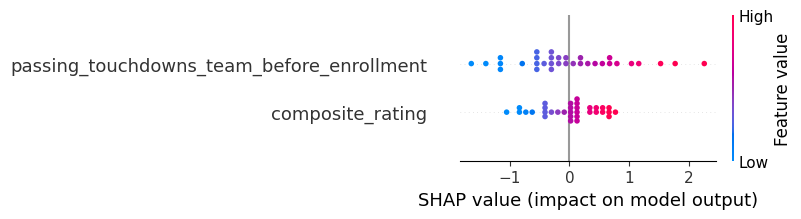

In [459]:
# Get the SHAP values for the model

linearegression = LinearRegression()

linearegression.fit(X_train_scaled, y_train)

import shap
explainer = shap.LinearExplainer(linearegression, X_train_scaled)
shap_values = explainer(X_train_scaled)
shap.summary_plot(shap_values, X_train_scaled, feature_names = X.columns)

Using only important model features, let's create the next model.

## **Model 7:**

In [458]:
# Create new predictor and target set:
X = players[['composite_rating',
       'passing_touchdowns_team_before_enrollment']]

y = players['TD/INT_Ratio_player_after_enrollment']

# With the reduced set of features, split the data into training and testing sets again
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale the features again
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create linear regression model
model_7 = sm.OLS(y_train, X_train_scaled).fit()

# Get the summary of the model
print(model_7.summary())

                                          OLS Regression Results                                         
Dep. Variable:     TD/INT_Ratio_player_after_enrollment   R-squared (uncentered):                   0.127
Model:                                              OLS   Adj. R-squared (uncentered):              0.071
Method:                                   Least Squares   F-statistic:                              2.259
Date:                                  Fri, 05 Jun 2026   Prob (F-statistic):                       0.121
Time:                                          13:42:52   Log-Likelihood:                         -85.452
No. Observations:                                    33   AIC:                                      174.9
Df Residuals:                                        31   BIC:                                      177.9
Df Model:                                             2                                                  
Covariance Type:                              

Even after progressively going through and eliminating/ adding features, a linear regression model does not seem to have any successful results. The only thing of note is that the passing touchdowns of a team the year before a player got there seems to have an affect on a recruits TD/Int ratio. 'passing_touchdowns_team_before_enrollment'

Let's try Lasso Next

---
# Lasso Regression
---

First, Let's try the intial set of predictor variables and see how the model performs. To make this process easier, let's use LassoCV(), which is lasso regression with built in cross validation to find the best model, given the feature set.

## **Model 1:**

In [460]:
# Create predictor set
X = players[['height', 'weight',
       'composite_rating', 'Is_FBS', 'Is_SEC',
       'Is_Big_Ten', 'Is_Big_XII', 'pos_DUAL', 'pos_PRO',
       'star_3', 'star_4', 'star_5', 'Is_Top_Five_Ranked',
       'Is_From_East',  'Accuracy_sentiment_score', 'Arm_Strength_sentiment_score',
       'Mobility_and_Athleticism_sentiment_score',
       'Pocket_Presence_sentiment_score', 'Size_and_Physical_sentiment_score', 'passing_pct_team_before_enrollment',
       'passing_yards_team_before_enrollment',
       'passing_touchdowns_team_before_enrollment', 'rushing_average_team_before_enrollment',
       'rushing_touchdowns_team_before_enrollment', 'offensive_yards_team_before_enrollment', 'penalty_counts_team_before_enrollment', 'fumbles_team_before_enrollment',
       'interceptions_team_before_enrollment', 'overall_wins_team_before_enrollment',
       'overall_losses_team_before_enrollment', 'ppg_offense_team_before_enrollment',
       'ppg_defense_team_before_enrollment', 'srs_team_before_enrollment',  'final_ranking_team_AP_top_10_before_enrollment',
       'highest_ranking_team_AP_top_10_before_enrollment']]

# Create target set
y = players['TD/INT_Ratio_player_after_enrollment']

# With the reduced set of features, split the data into training and testing sets again
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale the features again
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create LassoCV() object with specialized arguments
lasso_cv = LassoCV(
    alphas=np.logspace(-3, 2, 100),
    cv=10,
    max_iter=10000,
    random_state=42,
)

# Fit train set
lasso_cv.fit(X_train_scaled, y_train)

# Get predictions
y_pred_lasso = lasso_cv.predict(X_test_scaled)

# Get R^2
r2 = r2_score(y_test, y_pred_lasso)

# Print out important metrics
print(f"Best alpha:  {lasso_cv.alpha_:.4f}")
print(f"RMSE:        {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.4f}")
print(f"R²:          {r2:.4f}")

# get r2 adj score
n = len(y_test)  # number of observations
p = X_train.shape[1]  # number of predictors (features)
adj_r2_elas = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
print(f"Adjusted R²: {adj_r2_elas}")

# ── See which features were zeroed out ────────────────────────────────────────
feature_cols = X.columns

coef_df = pd.DataFrame({
    "feature":     feature_cols,
    "coefficient": lasso_cv.coef_,
}).sort_values("coefficient", ascending=False)

print("\nCoefficients (zero = dropped by Lasso):")
print(coef_df.to_string(index=False))

n_dropped = (lasso_cv.coef_ == 0).sum()
print(f"\nFeatures dropped: {n_dropped} / {len(feature_cols)}")

Best alpha:  0.4229
RMSE:        1.6050
R²:          -3.1517
Adjusted R²: 2.2301389555164857

Coefficients (zero = dropped by Lasso):
                                         feature  coefficient
       passing_touchdowns_team_before_enrollment     0.560408
                              Is_Top_Five_Ranked     0.283433
                                composite_rating     0.047735
                                          weight    -0.000000
                                          height    -0.000000
                                      Is_Big_Ten     0.000000
                                          Is_FBS     0.000000
                                        pos_DUAL     0.000000
                                         pos_PRO     0.000000
                                          star_3    -0.000000
                                          Is_SEC     0.000000
                                          star_4    -0.000000
                                          star_5     0.00000

From the output above, we can see that at the best alpha value (tunes the model's penalty term), there are a lot of predictors whose coefficeints are shrunken down to zero. The best practice is eliminatint variables whose value is 0. For model 2, this practice will be implemented.

## **Model 2:**

In [462]:
# Create predictor set
X = players[['composite_rating', 'Is_Top_Five_Ranked',
       'passing_touchdowns_team_before_enrollment']]

# Create target set
y = players['TD/INT_Ratio_player_after_enrollment']

# With the reduced set of features, split the data into training and testing sets again
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale the features again
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create LassoCV() object with specialized arguments
lasso_cv = LassoCV(
    alphas=np.logspace(-3, 2, 100),
    cv=10,
    max_iter=10000,
    random_state=42,
)

# Fit train set
lasso_cv.fit(X_train_scaled, y_train)

# Get predictions
y_pred_lasso = lasso_cv.predict(X_test_scaled)

# Get R^2
r2 = r2_score(y_test, y_pred_lasso)

# Print out important metrics
print(f"Best alpha:  {lasso_cv.alpha_:.4f}")
print(f"RMSE:        {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.4f}")
print(f"R²:          {r2:.4f}")

# get r2 adj score
n = len(y_test)  # number of observations
p = X_train.shape[1]  # number of predictors (features)
adj_r2_elas = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
print(f"Adjusted R²: {adj_r2_elas}")

# ── See which features were zeroed out ────────────────────────────────────────
feature_cols = X.columns

coef_df = pd.DataFrame({
    "feature":     feature_cols,
    "coefficient": lasso_cv.coef_,
}).sort_values("coefficient", ascending=False)

print("\nCoefficients (zero = dropped by Lasso):")
print(coef_df.to_string(index=False))

n_dropped = (lasso_cv.coef_ == 0).sum()
print(f"\nFeatures dropped: {n_dropped} / {len(feature_cols)}")

Best alpha:  0.0018
RMSE:        1.7550
R²:          -3.9638
Adjusted R²: -6.942063719216999

Coefficients (zero = dropped by Lasso):
                                  feature  coefficient
passing_touchdowns_team_before_enrollment     0.785481
                       Is_Top_Five_Ranked     0.466884
                         composite_rating     0.209476

Features dropped: 0 / 3


Very poor fit.